In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt



In [2]:
df = pd.read_excel('1/rccarbonation.xlsx')
print("Shape:", df.shape)
print("Colunas:", list(df.columns))
print("\nPrimeiras linhas:")
display(df)

Shape: (20000, 7)
Colunas: ['CCO₂ (%)', 'fc (MPa)', 'RH (%)', 'Type of cement', 'Exposure conditions', 't (years)', 'Possan']

Primeiras linhas:


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,CPII Z,PIA,9,10.1384
1,0.07,21.7,43.8,CPV - ARI,UEA,92,23.2231
2,0.08,30.3,83.7,CPIV,UEA,58,13.2715
3,0.15,22.8,37.6,CPIV,PIA,42,45.1498
4,0.03,26.4,65.2,CPII F,UEA,96,22.6178
...,...,...,...,...,...,...,...
19995,0.19,39.2,43.6,CPII Z,PIA,91,23.9632
19996,0.15,45.0,35.3,CPII F,PIA,26,7.5256
19997,0.28,36.0,42.9,CPIV,PIA,87,34.9459
19998,0.16,34.1,84.9,CPV - ARI,PEA,27,5.5076


In [3]:
palavras_exposure_conditions = (
    df['Exposure conditions']  # Seleciona a coluna de interesse
    .astype(str)      # Garante que os dados são do tipo string
    .unique()             # Obtém valores únicos
)
num_palavras_exposure_conditions = len(palavras_exposure_conditions)
print(f"Número de palavras distintas: {num_palavras_exposure_conditions}")
print(f"Palavras: {palavras_exposure_conditions}")
print("--------------------------------------------------")
palavras_type_cement = (
    df['Type of cement']  # Seleciona a coluna de interesse
    .astype(str)      # Garante que os dados são do tipo string
    .unique()             # Obtém valores únicos
)
num_palavras_type_cement = len(palavras_type_cement)
print(f"Número de palavras distintas: {num_palavras_type_cement}")
print(f"Palavras: {palavras_type_cement}")

# Define o mapeamento das palavras
mapeamento = {
    r'\bPIA\b': '0',
    r'\bUEA\b': '1',
    r'\bPEA\b': '2',
    r'\bCPII Z\b': '0',
    r'\bCPV - ARI\b': '1',
    r'\bCPIV\b': '2',
    r'\bCPII F\b': '3',
    r'\bCPIII\b': '4',
    r'\bCPII E\b': '5',
    
}

df[['Exposure conditions','Type of cement']] = df[['Exposure conditions','Type of cement']].replace(mapeamento, regex=True)
display(df)

Número de palavras distintas: 3
Palavras: ['PIA ' 'UEA ' 'PEA ']
--------------------------------------------------
Número de palavras distintas: 6
Palavras: ['CPII Z' 'CPV - ARI' 'CPIV' 'CPII F' 'CPIII' 'CPII E']


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178
...,...,...,...,...,...,...,...
19995,0.19,39.2,43.6,0,0,91,23.9632
19996,0.15,45.0,35.3,3,0,26,7.5256
19997,0.28,36.0,42.9,2,0,87,34.9459
19998,0.16,34.1,84.9,1,2,27,5.5076


In [4]:
def predict_carbonation(CCO2, fc, RH, type_of_cement, exposure_conditions, time_list):
    """
    Faz previsões de carbonatação para uma lista de tempos
    
    Parâmetros:
    - CCO2: Conteúdo de CO2 (%)
    - fc: Resistência do concreto (MPa)
    - RH: Umidade relativa (%)
    - type_of_cement: Tipo de cimento (string)
    - exposure_conditions: Condições de exposição (string)
    - time_list: Lista de tempos em anos para prever
    
    Retorna:
    - DataFrame com tempos e previsões
    """
    
    predictions = []
    
    for time in time_list:
        # Criar DataFrame com os dados de entrada
        input_data = pd.DataFrame({
            'CCO₂ (%)': [CCO2],
            'fc (MPa)': [fc],
            'RH (%)': [RH],
            'Type of cement': [type_of_cement],
            'Exposure conditions': [exposure_conditions],
            't (years)': [time]
        })


    X = df.drop('Possan', axis=1)
    y = df['Possan']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Tamanho do treino: {len(X_train)} samples")
    print(f"Tamanho do teste: {len(X_test)} samples")
    print(X_train.shape, X_test.shape)

    modelos = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(),
        "Lasso": Lasso(),
        "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
        "RandomForestRegressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
        "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    }

    resultados = {}

    for nome, model in modelos.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        resultados[nome] = r2
        print(f"{nome}: R² = {r2:.4f}")

    melhor_modelo_nome = max(resultados, key=resultados.get)
    melhor_r2 = resultados[melhor_modelo_nome]
    melhor_modelo = modelos[melhor_modelo_nome]

    print("\nMelhor modelo encontrado:")
    print(f"{melhor_modelo_nome} com R² = {melhor_r2:.4f}")
    # Construir DataFrame de entrada para todos os tempos
    pred_rows = []
    for t in time_list:
        pred_rows.append({
            'CCO₂ (%)': CCO2,
            'fc (MPa)': fc,
            'RH (%)': RH,
            'Type of cement': type_of_cement,
            'Exposure conditions': exposure_conditions,
            't (years)': t
        })
    pred_input_df = pd.DataFrame(pred_rows)

    # Garante que as colunas estejam na mesma ordem que X_train (adiciona colunas faltantes com NaN)
    for col in X_train.columns:
        if col not in pred_input_df.columns:
            pred_input_df[col] = np.nan
    pred_input_df = pred_input_df[X_train.columns]

    # Tentar prever; se falhar, preencher com NaN
    try:
        preds = melhor_modelo.predict(pred_input_df)
    except Exception:
        preds = np.full(len(time_list), np.nan)

    results_df = pd.DataFrame({
        "Tempo (anos)": time_list,
        "Carbonatação Prevista (mm)": preds
    })
    
    
    return results_df

Dicionário de mapeamento
- Type of cement:
    - CPII Z -> 0
    - CPV - ARI -> 1
    - CPIV -> 2
    - CPII F -> 3
    - CPIII -> 4
    - CPII E -> 5

- Exposure conditions:
    - PIA -> 0
    - UEA -> 1
    - PEA -> 2


In [17]:
# Lista de tempos
time_list = [1, 5, 10, 20, 30, 40, 45, 50, 55, 60, 80, 100]
#teste baseando na segunda linha do dataframe original
results_df = predict_carbonation(
    CCO2 = 0.28,
    fc = 36.0,        # Resistência do concreto (MPa)
    RH = 42.9,        # Umidade relativa (%)
    type_of_cement = "2",          # Tipo de cimento
    exposure_conditions = "0" ,       # Condições de exposição
    time_list=time_list
)


Tamanho do treino: 16000 samples
Tamanho do teste: 4000 samples
(16000, 6) (4000, 6)
LinearRegression: R² = 0.5505
Ridge: R² = 0.5505
Lasso: R² = 0.5363
DecisionTreeRegressor: R² = 0.9143
RandomForestRegressor: R² = 0.9583
GradientBoostingRegressor: R² = 0.9468
HistGradientBoostingRegressor: R² = 0.9922

Melhor modelo encontrado:
HistGradientBoostingRegressor com R² = 0.9922


In [19]:
display(results_df)

,Tempo (anos),Carbonatação Prevista (mm)
0,1,4.839728
1,5,8.585119
2,10,11.407207
3,20,15.784207
4,30,20.334861
5,40,23.435802
6,45,25.796739
7,50,28.017446
8,55,28.101974
9,60,30.027801


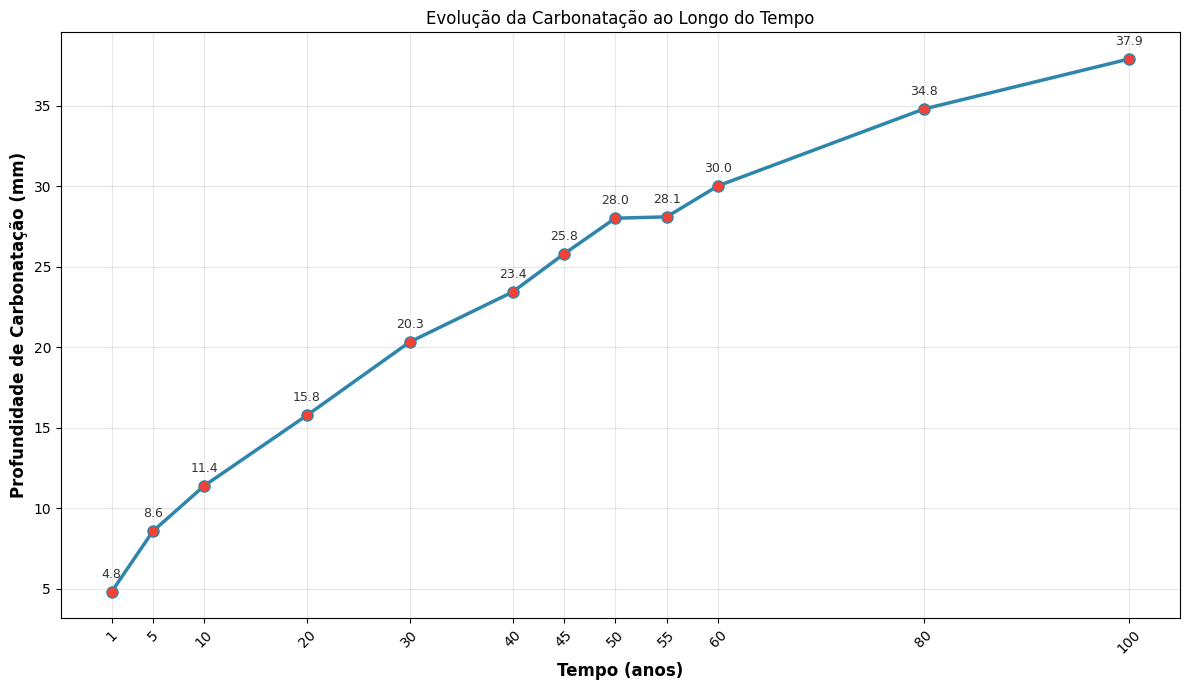

In [20]:
# Plotar Gráfico Tempo vs Carbonatação
plt.figure(figsize=(12, 7))

# Gráfico principal
plt.plot(results_df['Tempo (anos)'], results_df['Carbonatação Prevista (mm)'],
        marker='o', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='#F24236')

# Customização do gráfico
plt.xlabel('Tempo (anos)', fontsize=12, fontweight='bold')
plt.ylabel('Profundidade de Carbonatação (mm)', fontsize=12, fontweight='bold')
plt.title(f'Evolução da Carbonatação ao Longo do Tempo')

plt.grid(True, alpha=0.3)
plt.xticks(time_list, rotation=45)

# Adicionar valores nos pontos
for i, row in results_df.iterrows():
        plt.annotate(f'{row["Carbonatação Prevista (mm)"]:.1f}',
                (row['Tempo (anos)'], row['Carbonatação Prevista (mm)']),
                textcoords="offset points", xytext=(0,10), ha='center',
                fontsize=9, alpha=0.8)


plt.tight_layout()
plt.show()